# **Experiment_3D: Logistic Regression on a Small Dataset**

## Problem Statement

Consider a very small dataset representing the relationship between the number of hours studied and the exam result (pass or fail).

- Let **X** denote the number of hours studied.
- Let **Y** denote the exam outcome, where:
  - Pass = 1
  - Fail = 0

The objective is to apply **Logistic Regression** on this dataset and analyze the effect of different learning rates on convergence.

---

## Dataset

| Number of Hours Studied (X) | Result (Y) |
|----------------------------|------------|
| 1                          | 0          |
| 2                          | 0          |
| 3                          | 0          |
| 4                          | 1          |
| 5                          | 1          |

---

## Tasks

1. Perform logistic regression on the given dataset.
2. Define the sigmoid (logistic) function.
3. Calculate the cost (loss) function.
4. Apply gradient descent to minimize the cost function.
5. Use the following learning rates:
   - 0.1
   - 0.01
   - 0.001
6. Plot the following graphs:
   - Sigmoid (S-shaped) curve
   - Cost vs iterations for each learning rate
   - Loss function comparison for different learning rates
7. Compare the results and identify the most stable and optimal learning rate.

---

## Conclusion

This experiment demonstrates how different learning rates affect the convergence behavior of gradient descent in logistic regression when applied to a small dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dataset
X = np.array([1, 2, 3, 4, 5])
Y = np.array([0, 0, 0, 1, 1])

In [3]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [4]:
# Cost function
def cost_function(X, Y, w, b):
    m = len(Y)
    z = w * X + b
    y_hat = sigmoid(z)
    cost = -(1/m) * np.sum(Y*np.log(y_hat + 1e-9) + (1-Y)*np.log(1-y_hat + 1e-9))
    return cost

In [5]:
# Gradient Descent
def gradient_descent(X, Y, lr, iterations):
    w, b = 0.0, 0.0
    cost_list = []

    m = len(Y)

    for i in range(iterations):
        z = w * X + b
        y_hat = sigmoid(z)

        dw = (1/m) * np.sum((y_hat - Y) * X)
        db = (1/m) * np.sum(y_hat - Y)

        w = w - lr * dw
        b = b - lr * db

        cost = cost_function(X, Y, w, b)
        cost_list.append(cost)

    return w, b, cost_list

In [6]:
learning_rates = [0.1, 0.01, 0.001]
iterations = 100

results = {}

for lr in learning_rates:
    w, b, cost_list = gradient_descent(X, Y, lr, iterations)
    results[lr] = (w, b, cost_list)

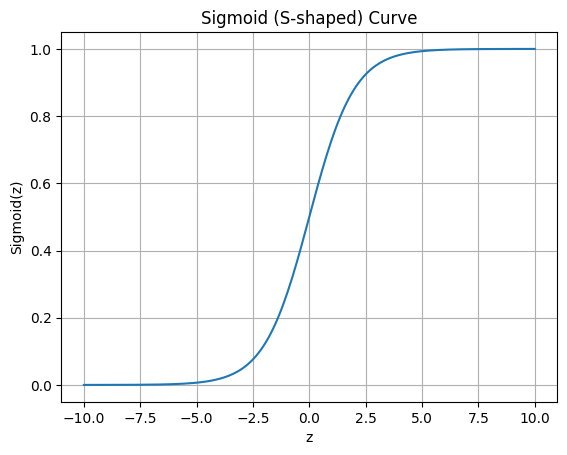

In [7]:
# Sigmoid S-curve Plot
x_curve = np.linspace(-10, 10, 200)
y_curve = sigmoid(x_curve)

plt.figure()
plt.plot(x_curve, y_curve)
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid (S-shaped) Curve")
plt.grid(True)
plt.show()

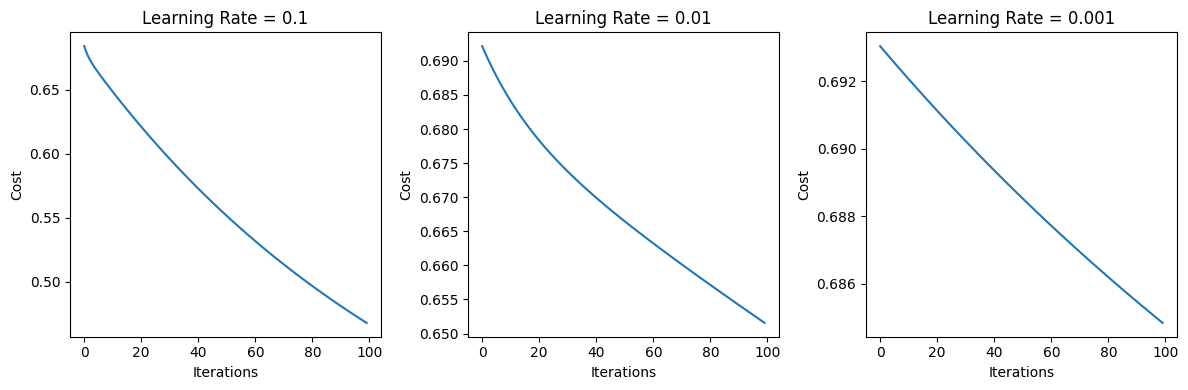

In [8]:
# Cost vs Iterations (Side by Side)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(results[0.1][2])
plt.title("Learning Rate = 0.1")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.subplot(1,3,2)
plt.plot(results[0.01][2])
plt.title("Learning Rate = 0.01")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.subplot(1,3,3)
plt.plot(results[0.001][2])
plt.title("Learning Rate = 0.001")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [10]:
# Final Results
print("Final Comparison:\n")

for lr in learning_rates:
    w, b, cost_list = results[lr]
    print(f"Learning Rate: {lr}")
    print(f"  Final Weight (w): {w:.4f}")
    print(f"  Final Bias (b): {b:.4f}")
    print(f"  Minimum Cost: {cost_list[-1]:.4f}")
    print("-" * 30)

Final Comparison:

Learning Rate: 0.1
  Final Weight (w): 0.4793
  Final Bias (b): -1.3746
  Minimum Cost: 0.4680
------------------------------
Learning Rate: 0.01
  Final Weight (w): 0.1282
  Final Bias (b): -0.1439
  Minimum Cost: 0.6516
------------------------------
Learning Rate: 0.001
  Final Weight (w): 0.0266
  Final Bias (b): -0.0109
  Minimum Cost: 0.6848
------------------------------


**Extra Checking for Better Understanding**

In [12]:
# Cost Function (Quadratic)
def cost_function(x):
    return (x + 5)**2

# Gradient of Cost Function
def gradient(x):
    return 2*(x + 5)

# Gradient Descent
def gradient_descent(lr, iterations=100):
    x = -4     # initial value
    path = []

    for _ in range(iterations):
        path.append(x)
        x = x - lr * gradient(x)

    return np.array(path)

In [13]:
# Setup
learning_rates = [0.1, 0.01, 0.001]
x_curve = np.linspace(-10, 5, 200)
y_curve = cost_function(x_curve)

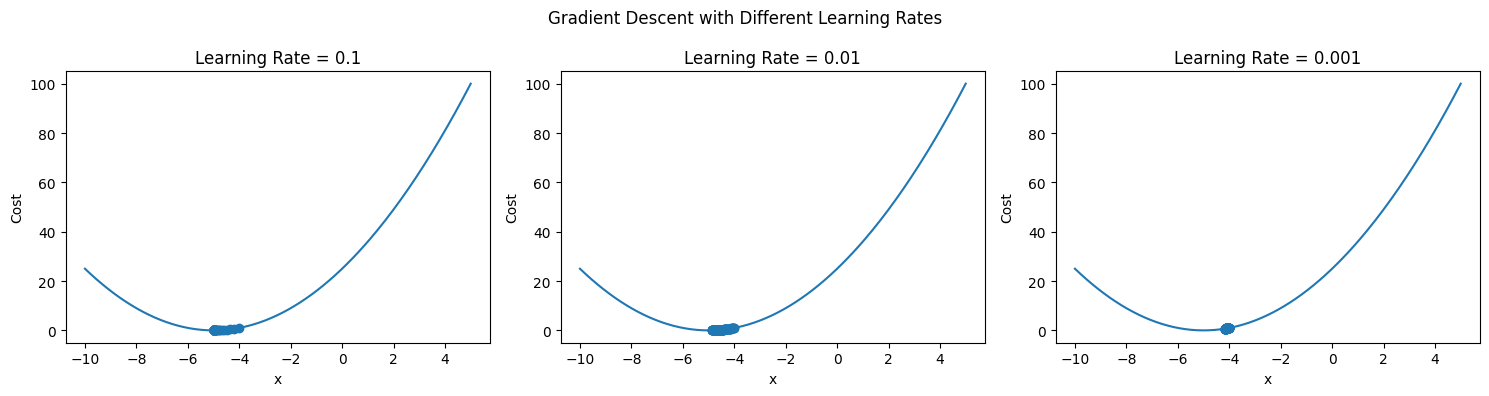

In [14]:
plt.figure(figsize=(15,4))

for i, lr in enumerate(learning_rates):
    path = gradient_descent(lr)

    plt.subplot(1,3,i+1)
    plt.plot(x_curve, y_curve)                     # cost curve
    plt.scatter(path, cost_function(path))         # GD steps
    plt.title(f"Learning Rate = {lr}")
    plt.xlabel("x")
    plt.ylabel("Cost")

plt.suptitle("Gradient Descent with Different Learning Rates")
plt.tight_layout()
plt.show()